## Purpose

Combine SEND energy data with Solcast weather data.

The notebook calculates renewable generation, campus net load and a potential renewable-surplus proxy. This is not the same as measured curtailment.

In [9]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the root or Notebooks directory."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing Data/ and Notebooks/.")


ROOT = find_project_root()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = DATA_DIR / "Results"
PROCESSED_DIR = DATA_DIR / "Processed"
FIGURES_DIR = ROOT / "Figures"
MODELS_DIR = ROOT / "Models" / "Forecasting"

for directory in [RESULTS_DIR, PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INTERVAL_MINUTES = 5
INTERVAL_HOURS = INTERVAL_MINUTES / 60
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Project root: {ROOT}")

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project


In [10]:
def save_table(df: pd.DataFrame, path: Path) -> Path:
    """Save Parquet where available, otherwise save CSV with the same stem."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix.lower() == ".parquet":
        try:
            df.to_parquet(path, index=False)
            print(f"Saved: {path.relative_to(ROOT)}")
            return path
        except (ImportError, ModuleNotFoundError) as exc:
            csv_path = path.with_suffix(".csv")
            df.to_csv(csv_path, index=False)
            print(f"Parquet engine unavailable ({exc.__class__.__name__}); saved CSV: {csv_path.relative_to(ROOT)}")
            return csv_path
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def read_table(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    """Read a Parquet/CSV output regardless of which format was written."""
    candidates = [path]
    if path.suffix.lower() == ".parquet":
        candidates.append(path.with_suffix(".csv"))
    elif path.suffix.lower() == ".csv":
        candidates.append(path.with_suffix(".parquet"))

    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix.lower() == ".parquet":
                return pd.read_parquet(candidate)
            return pd.read_csv(candidate, parse_dates=parse_dates)
    raise FileNotFoundError(f"None of these files exists: {candidates}")

## 1. Load and combine SEND and Solcast data

In [11]:
def load_annual_data(year: int) -> pd.DataFrame:
    deop_path = DATA_DIR / "DEOP" / f"{year}_DEOP_Repaired.csv"
    solcast_path = DATA_DIR / "Solcast" / f"Solcast_{year}.csv"

    if not deop_path.exists():
        raise FileNotFoundError(deop_path)
    if not solcast_path.exists():
        raise FileNotFoundError(solcast_path)

    deop = pd.read_csv(deop_path, parse_dates=["DateTime"])
    solcast = pd.read_csv(solcast_path, parse_dates=["DateTime"])

    deop = deop.rename(columns={
        "power-con-ave": "consumption_kw",
        "power-gen-wt-ave": "wind_kw",
        "power-gen-pv-ave": "solar_kw",
    })

    deop["DateTime"] = pd.to_datetime(deop["DateTime"], errors="coerce")
    solcast["DateTime"] = pd.to_datetime(solcast["DateTime"], errors="coerce")

    deop = deop.dropna(subset=["DateTime"]).sort_values("DateTime")
    solcast = solcast.dropna(subset=["DateTime"]).sort_values("DateTime")

    deop = deop.drop_duplicates("DateTime", keep="last")
    solcast = solcast.drop_duplicates("DateTime", keep="last")

    merged = deop.merge(solcast, on="DateTime", how="left", validate="one_to_one")
    merged["source_year"] = year
    return merged


data = pd.concat([load_annual_data(2022), load_annual_data(2023)], ignore_index=True)
data = data.sort_values("DateTime").drop_duplicates("DateTime", keep="last").reset_index(drop=True)

print(data.shape)
display(data.head())
print(data[["DateTime", "solar_kw", "wind_kw", "consumption_kw"]].tail())

(193247, 14)


,DateTime,consumption_kw,wind_kw,solar_kw,air_temp,gti,surface_pressure,snow_depth,cloud_opacity,ghi,clearsky_gti,wind_speed_100m,weather_type,source_year
0,2022-03-01 00:00:00,0.0,20.708989,0.0,5,0,1006.3,0.0,60.6,0,0,5.7,OVERCAST,2022
1,2022-03-01 00:05:00,0.0,31.507760,0.0,5,0,1006.3,0.0,63.4,0,0,5.8,OVERCAST,2022
2,2022-03-01 00:10:00,0.0,24.946394,0.0,5,0,1006.4,0.0,62.6,0,0,5.8,OVERCAST,2022
3,2022-03-01 00:15:00,0.0,24.961075,0.0,5,0,1006.4,0.0,61.4,0,0,5.8,OVERCAST,2022
4,2022-03-01 00:20:00,0.0,26.129103,0.0,5,0,1006.4,0.0,60.1,0,0,5.9,OVERCAST,2022


                  DateTime  solar_kw  wind_kw  consumption_kw
193242 2023-12-31 23:35:00       0.0  666.773        1331.379
193243 2023-12-31 23:40:00       0.0  757.118        1333.050
193244 2023-12-31 23:45:00       0.0  518.613        1378.813
193245 2023-12-31 23:50:00       0.0  838.549        1198.752
193246 2023-12-31 23:55:00       0.0  683.698        1278.754


## 2. Quality checks and derived energy variables

In [12]:
ENERGY_COLUMNS = ["solar_kw", "wind_kw", "consumption_kw"]
for column in ENERGY_COLUMNS:
    data[column] = pd.to_numeric(data[column], errors="coerce")
    data[f"{column}_missing"] = data[column].isna()
    data[f"{column}_negative"] = data[column] < 0

quality_summary = pd.DataFrame({
    "missing": data[ENERGY_COLUMNS].isna().sum(),
    "negative": (data[ENERGY_COLUMNS] < 0).sum(),
    "minimum": data[ENERGY_COLUMNS].min(),
    "maximum": data[ENERGY_COLUMNS].max(),
})
display(quality_summary)

# Treat demand and generation as positive values.
# Keep negative values only for quality checks.
solar = data["solar_kw"].clip(lower=0)
wind = data["wind_kw"].clip(lower=0)
consumption = data["consumption_kw"].clip(lower=0)

# Long zero-demand periods look like missing data.
# Treat them as missing so they do not create fake surplus.
data["consumption_zero_flag"] = consumption.eq(0)
data["surplus_input_valid"] = consumption.gt(0) & solar.notna() & wind.notna()

data["renewable_kw"] = solar + wind
data["net_load_kw"] = np.where(
    data["surplus_input_valid"], consumption - data["renewable_kw"], np.nan
)
data["surplus_kw"] = pd.Series(-data["net_load_kw"], index=data.index).clip(lower=0)
data["renewable_deficit_kw"] = pd.Series(data["net_load_kw"], index=data.index).clip(lower=0)

for power_column in ["solar_kw", "wind_kw", "consumption_kw", "renewable_kw", "surplus_kw"]:
    data[f"{power_column.removesuffix('_kw')}_kwh"] = data[power_column].clip(lower=0) * INTERVAL_HOURS

# Add calendar columns for later notebooks.
data["date"] = data["DateTime"].dt.date.astype(str)
data["hour"] = data["DateTime"].dt.hour
data["minute"] = data["DateTime"].dt.minute
data["day_of_week"] = data["DateTime"].dt.dayofweek
data["is_weekend"] = data["day_of_week"].ge(5).astype(int)
data["month"] = data["DateTime"].dt.month

display(data[["DateTime", "renewable_kw", "consumption_kw", "net_load_kw", "surplus_kw"]].head())

,missing,negative,minimum,maximum
solar_kw,0,0,0.0,4629.429381
wind_kw,0,0,0.0,21357.019490
consumption_kw,0,0,0.0,4165.575000


,DateTime,renewable_kw,consumption_kw,net_load_kw,surplus_kw
0,2022-03-01 00:00:00,20.708989,0.0,NaN,NaN
1,2022-03-01 00:05:00,31.507760,0.0,NaN,NaN
2,2022-03-01 00:10:00,24.946394,0.0,NaN,NaN
3,2022-03-01 00:15:00,24.961075,0.0,NaN,NaN
4,2022-03-01 00:20:00,26.129103,0.0,NaN,NaN


## 3. Identify contiguous surplus events

In [13]:
SURPLUS_THRESHOLD_KW = 1.0
is_surplus = data["surplus_kw"].fillna(0).gt(SURPLUS_THRESHOLD_KW)
new_event = is_surplus.ne(is_surplus.shift(fill_value=False))
event_counter = new_event.cumsum()
data["surplus_event_id"] = np.where(is_surplus, event_counter, np.nan)

events = (
    data.dropna(subset=["surplus_event_id"])
    .groupby("surplus_event_id", as_index=False)
    .agg(
        start_time=("DateTime", "min"),
        end_time=("DateTime", "max"),
        interval_count=("DateTime", "size"),
        peak_surplus_kw=("surplus_kw", "max"),
        mean_surplus_kw=("surplus_kw", "mean"),
        surplus_energy_kwh=("surplus_kwh", "sum"),
    )
)
events["duration_minutes"] = events["interval_count"] * INTERVAL_MINUTES

daily_surplus = (
    data.groupby("date", as_index=False)
    .agg(
        renewable_energy_kwh=("renewable_kwh", "sum"),
        campus_energy_kwh=("consumption_kwh", "sum"),
        surplus_energy_kwh=("surplus_kwh", "sum"),
        peak_surplus_kw=("surplus_kw", "max"),
        valid_intervals=("surplus_input_valid", "sum"),
        total_intervals=("DateTime", "size"),
        surplus_intervals=("surplus_kw", lambda s: int((s > SURPLUS_THRESHOLD_KW).sum())),
    )
)
daily_surplus["data_completeness"] = daily_surplus["valid_intervals"] / daily_surplus["total_intervals"]
daily_surplus = daily_surplus.sort_values("surplus_energy_kwh", ascending=False)

display(events.sort_values("surplus_energy_kwh", ascending=False).head(10))
display(daily_surplus.head(10))

,surplus_event_id,start_time,end_time,interval_count,peak_surplus_kw,mean_surplus_kw,surplus_energy_kwh,duration_minutes
3069,6139.0,2023-07-07 07:35:00,2023-07-07 16:20:00,106,3015.486381,1439.299897,12713.815756,530
3075,6151.0,2023-07-09 08:45:00,2023-07-09 14:25:00,69,3500.058734,1835.197066,10552.383127,345
210,421.0,2022-05-14 08:00:00,2022-05-14 16:30:00,103,1523.840000,996.763922,8555.557000,515
739,1479.0,2022-06-26 06:00:00,2022-06-26 17:00:00,133,1376.591000,759.568609,8418.552083,665
2346,4693.0,2023-04-22 07:10:00,2023-04-22 15:50:00,105,2291.222320,959.792244,8398.182139,525
2196,4393.0,2023-04-07 08:30:00,2023-04-07 16:10:00,93,1488.962000,1081.868419,8384.480250,465
24,49.0,2022-04-16 08:30:00,2022-04-16 16:05:00,92,1624.640000,969.010793,7429.082750,460
28,57.0,2022-04-17 07:55:00,2022-04-17 16:05:00,99,1419.662000,877.829253,7242.091333,495
3660,7321.0,2023-09-05 08:10:00,2023-09-05 16:10:00,97,1465.892000,873.716990,7062.545667,485
140,281.0,2022-04-30 07:30:00,2022-04-30 15:40:00,99,1688.773000,795.891960,6566.108667,495


,date,renewable_energy_kwh,campus_energy_kwh,surplus_energy_kwh,peak_surplus_kw,valid_intervals,total_intervals,surplus_intervals,data_completeness
493,2023-07-07,37359.651338,38904.229917,12713.815756,3015.486381,288,288,106,1.0
495,2023-07-09,24080.665415,31463.751833,10552.383127,3500.058734,288,288,69,1.0
117,2022-06-26,32409.776750,29674.137333,9023.666000,1376.591000,288,288,151,1.0
488,2023-07-02,26323.755225,30997.244167,8810.713357,2373.734168,288,288,122,1.0
74,2022-05-14,28042.933583,32688.382917,8555.557000,1523.840000,288,288,103,1.0
402,2023-04-07,35193.686667,40784.114167,8399.886250,1488.962000,288,288,97,1.0
417,2023-04-22,23084.853116,32905.791978,8398.182139,2291.222320,288,288,105,1.0
551,2023-09-03,25661.897500,29287.396333,8332.003167,1568.537000,288,288,100,1.0
470,2023-06-14,40607.648833,44073.205167,7775.247750,1544.163000,288,288,110,1.0
137,2022-07-16,24187.175083,27130.303333,7744.069750,1516.704000,288,288,106,1.0


## 4. Optionally merge forecast outputs

In [14]:
# Merge forecast prediction columns when they are available.
prediction_candidates = [
    RESULTS_DIR / "surplus_predictions.parquet",
    RESULTS_DIR / "surplus_predictions.csv",
    RESULTS_DIR / "forecast_predictions.csv",
]

prediction_path = next((p for p in prediction_candidates if p.exists()), None)
if prediction_path is not None:
    predictions = read_table(prediction_path, parse_dates=["DateTime"])
    predictions["DateTime"] = pd.to_datetime(predictions["DateTime"], errors="coerce")
    prediction_columns = [c for c in predictions.columns if c != "DateTime"]
    data = data.merge(predictions[["DateTime", *prediction_columns]], on="DateTime", how="left")
    print(f"Merged forecast output: {prediction_path.name}")
else:
    print("No surplus forecast output found yet. Actual surplus remains available for perfect-information experiments.")

No surplus forecast output found yet. Actual surplus remains available for perfect-information experiments.


## 5. Save outputs

In [15]:
processed_path = save_table(data, PROCESSED_DIR / "send_solcast_surplus_5min.parquet")
save_table(events, RESULTS_DIR / "surplus_events.csv")
save_table(daily_surplus, RESULTS_DIR / "daily_surplus_summary.csv")

print(f"Study period: {data['DateTime'].min()} to {data['DateTime'].max()}")
print(f"Total potential surplus: {data['surplus_kwh'].sum():,.1f} kWh")
print(f"Number of surplus events: {len(events):,}")

Parquet engine unavailable (ImportError); saved CSV: Data/Processed/send_solcast_surplus_5min.csv
Saved: Data/Results/surplus_events.csv
Saved: Data/Results/daily_surplus_summary.csv
Study period: 2022-03-01 00:00:00 to 2023-12-31 23:55:00
Total potential surplus: 1,070,228.4 kWh
Number of surplus events: 4,035


## 6. Visualise the highest-surplus day

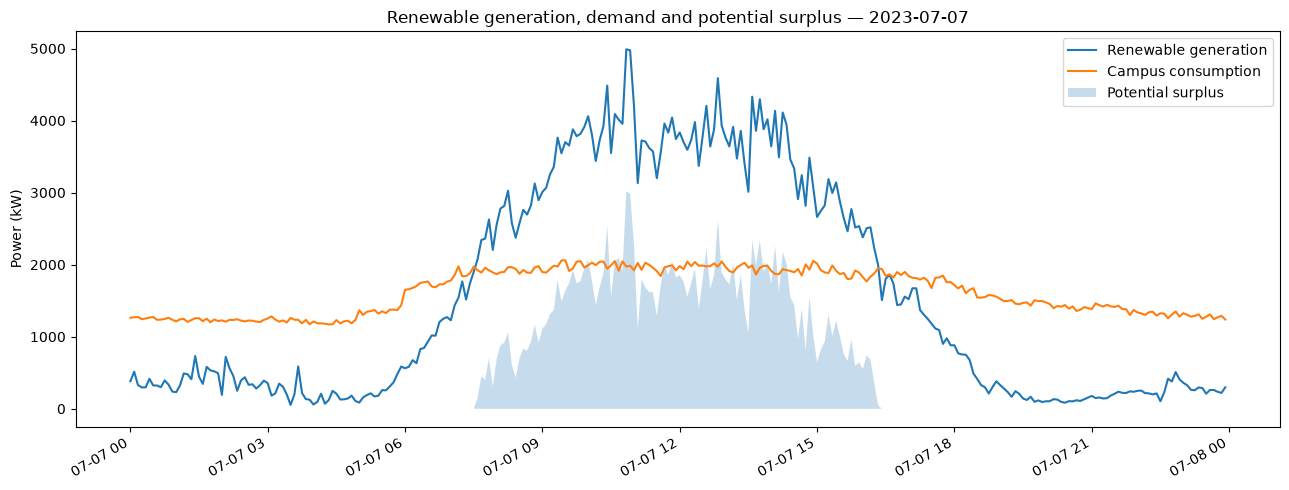

Saved: Figures/renewable_surplus_profile.png


In [16]:
if not daily_surplus.empty:
    selected_date = pd.Timestamp(daily_surplus.iloc[0]["date"])
    day = data[data["DateTime"].dt.normalize() == selected_date].copy()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(day["DateTime"], day["renewable_kw"], label="Renewable generation")
    ax.plot(day["DateTime"], day["consumption_kw"], label="Campus consumption")
    ax.fill_between(day["DateTime"], 0, day["surplus_kw"], alpha=0.25, label="Potential surplus")
    ax.set_title(f"Renewable generation, demand and potential surplus — {selected_date.date()}")
    ax.set_ylabel("Power (kW)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    figure_path = FIGURES_DIR / "renewable_surplus_profile.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {figure_path.relative_to(ROOT)}")

## Notebook outputs

- `Data/Processed/send_solcast_surplus_5min.parquet` (or CSV fallback)
- `Data/Results/surplus_events.csv`
- `Data/Results/daily_surplus_summary.csv`
- `Figures/renewable_surplus_profile.png`